# Market Timing vs Time in the Market in the Long Term

In [195]:
import numpy as np
import pandas as pd

In [196]:
prices=pd.read_csv("STOXX_600_TR_daily.csv", header=0, index_col=0)
prices.head()

,Open,High,Low,Close,Volume,Adjusted
Date,,,,,,
2006-01-02,310.010010,311.410004,310.010010,311.190002,0.0,311.190002
2006-01-03,311.089996,314.320007,311.089996,313.040009,0.0,313.040009
2006-01-04,313.179993,316.140015,313.179993,316.140015,0.0,316.140015
2006-01-05,315.890015,315.950012,314.880005,315.040009,0.0,315.040009
2006-01-06,314.929993,317.100006,314.929993,317.100006,0.0,317.100006


In [197]:
prices["Returns"]=prices["Adjusted"].pct_change(fill_method=None)

In [198]:
prices=prices.ffill(limit=1)
prices=prices.dropna()
prices = prices.drop(columns=["Open", "High", "Low","Close","Volume"])

In [199]:
prices

,Adjusted,Returns
Date,,
2006-01-03,313.040009,0.005945
2006-01-04,316.140015,0.009903
2006-01-05,315.040009,-0.003479
2006-01-06,317.100006,0.006539
2006-01-09,317.709991,0.001924
...,...,...
2025-12-19,587.500000,0.003673
2025-12-22,586.750000,-0.001277
2025-12-23,588.729980,0.003374


### Now that we have our Returns column we can move to create the wealth index for the lump sum

In [200]:
money=50000
prices["Lump Sum"] = money * (1 + prices["Returns"]).cumprod()
prices

,Adjusted,Returns,Lump Sum
Date,,,
2006-01-03,313.040009,0.005945,50297.247034
2006-01-04,316.140015,0.009903,50795.335995
2006-01-05,315.040009,-0.003479,50618.594118
2006-01-06,317.100006,0.006539,50949.581223
2006-01-09,317.709991,0.001924,51047.589730
...,...,...,...
2025-12-19,587.500000,0.003673,94182.765719
2025-12-22,586.750000,-0.001277,94062.532401
2025-12-23,588.729980,0.003374,94379.945229


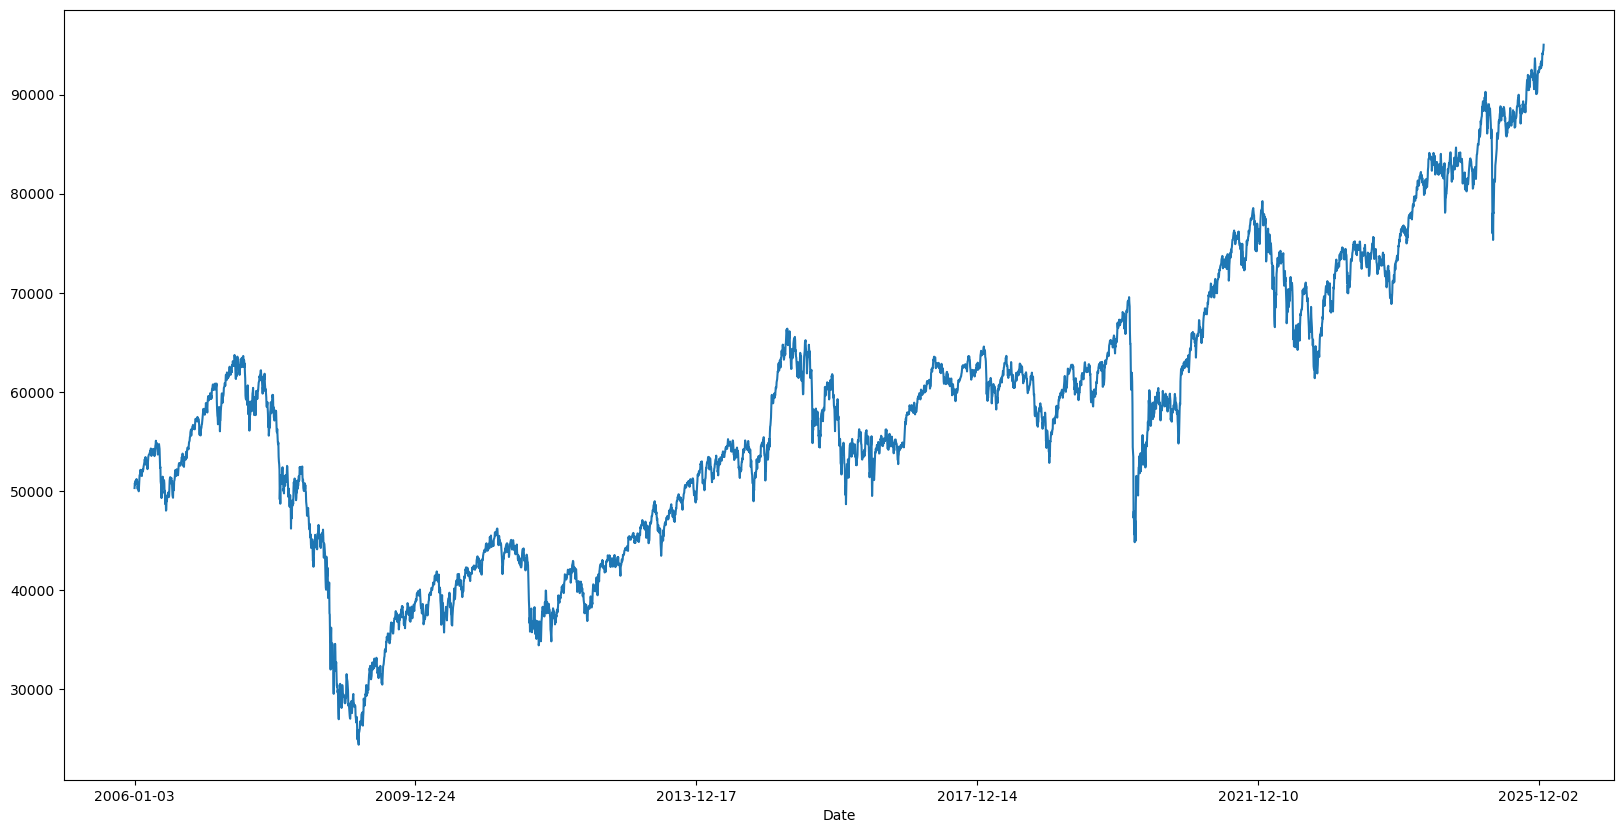

In [201]:
prices["Lump Sum"].plot(figsize=(20,10))
# Comaprison functions for later
def CAGR(wealth):
    return (wealth.iloc[-1] / wealth.iloc[0]) ** (252 / len(wealth)) - 1

def max_drawdown(wealth):
    dd = wealth / wealth.cummax() - 1
    return dd.min()

def ann_vol(returns):
    return returns.std() * np.sqrt(252)

def sharpe(returns, rf=0):
    return (returns.mean() * 252 - rf) / (returns.std() * np.sqrt(252))

In [215]:
# Stats for portfolio lump sum
cagr_lump=CAGR(prices["Lump Sum"])
print("CAGR of Lump Sum Portfolio --> ", cagr_lump*100,"%")
tot_return_lump=(prices["Lump Sum"].iloc[-1] - prices["Lump Sum"].iloc[0])/(prices["Lump Sum"].iloc[0])
print("Total Return of the Lump Sum Portfolio --> ", tot_return_lump*100,"%")
max_dd_lump=max_drawdown(prices["Lump Sum"])
print("Max Drawdown of the Lump Sum Portfolio is --> ", max_dd_lump*100,"%")
print("Minimum Daily Return -->", prices["Lump Sum"].pct_change().min() * 100, "% on", prices["Lump Sum"].pct_change().idxmin())
print("Maximum Daily Return -->", prices["Lump Sum"].pct_change().max() * 100, "% on", prices["Lump Sum"].pct_change().idxmax())
ann_vol_lump=ann_vol(prices["Lump Sum"].pct_change())
print("The annualized volatility of the Lump Sum Portfolio is --> ",ann_vol_lump*100,"%")

CAGR of Lump Sum Portfolio -->  3.246708831776801 %
Total Return of the Lump Sum Portfolio -->  88.93521728952543 %
Max Drawdown of the Lump Sum Portfolio is -->  -61.713495254744075 %
Minimum Daily Return --> -11.47762980183309 % on 2020-03-12
Maximum Daily Return --> 9.866908668938423 % on 2008-10-13
The annualized volatility of the Lump Sum Portfolio is -->  18.360054419435084 %


## Adding Cash Only adjsuted for Inflation 
This would mean a decrease in the nominal value, while in reality the nominal value would be 50k also on the last day, the only thing that really goes down is the purchasing power, so you could see this as value x of cash on the year y buys at that date the same stuff that that value X would have both in the start of the dataset

In [203]:
inflation=pd.read_csv("ECB_EU_INFLATION.csv", header=0, index_col=0)
inflation=inflation.drop(columns=["TIME PERIOD"])
inflation.columns = ["Values"]
inflation=inflation.dropna()
inflation["Values"]=(-inflation["Values"]/100.0)/12
inflation

,Values
DATE,
1997-01-31,-0.001750
1997-02-28,-0.001500
1997-03-31,-0.001250
1997-04-30,-0.001083
1997-05-31,-0.001167
...,...
2026-02-28,-0.001583
2026-03-31,-0.002167
2026-04-30,-0.002500


In [204]:
prices["Inflation"]=inflation
prices["Inflation"]=prices["Inflation"].fillna(0)
prices["Cash"] = money * (1 + prices["Inflation"]).cumprod()
prices

,Adjusted,Returns,Lump Sum,Inflation,Cash
Date,,,,,
2006-01-03,313.040009,0.005945,50297.247034,0.0,50000.000000
2006-01-04,316.140015,0.009903,50795.335995,0.0,50000.000000
2006-01-05,315.040009,-0.003479,50618.594118,0.0,50000.000000
2006-01-06,317.100006,0.006539,50949.581223,0.0,50000.000000
2006-01-09,317.709991,0.001924,51047.589730,0.0,50000.000000
...,...,...,...,...,...
2025-12-19,587.500000,0.003673,94182.765719,0.0,37049.014303
2025-12-22,586.750000,-0.001277,94062.532401,0.0,37049.014303
2025-12-23,588.729980,0.003374,94379.945229,0.0,37049.014303


<Axes: xlabel='Date'>

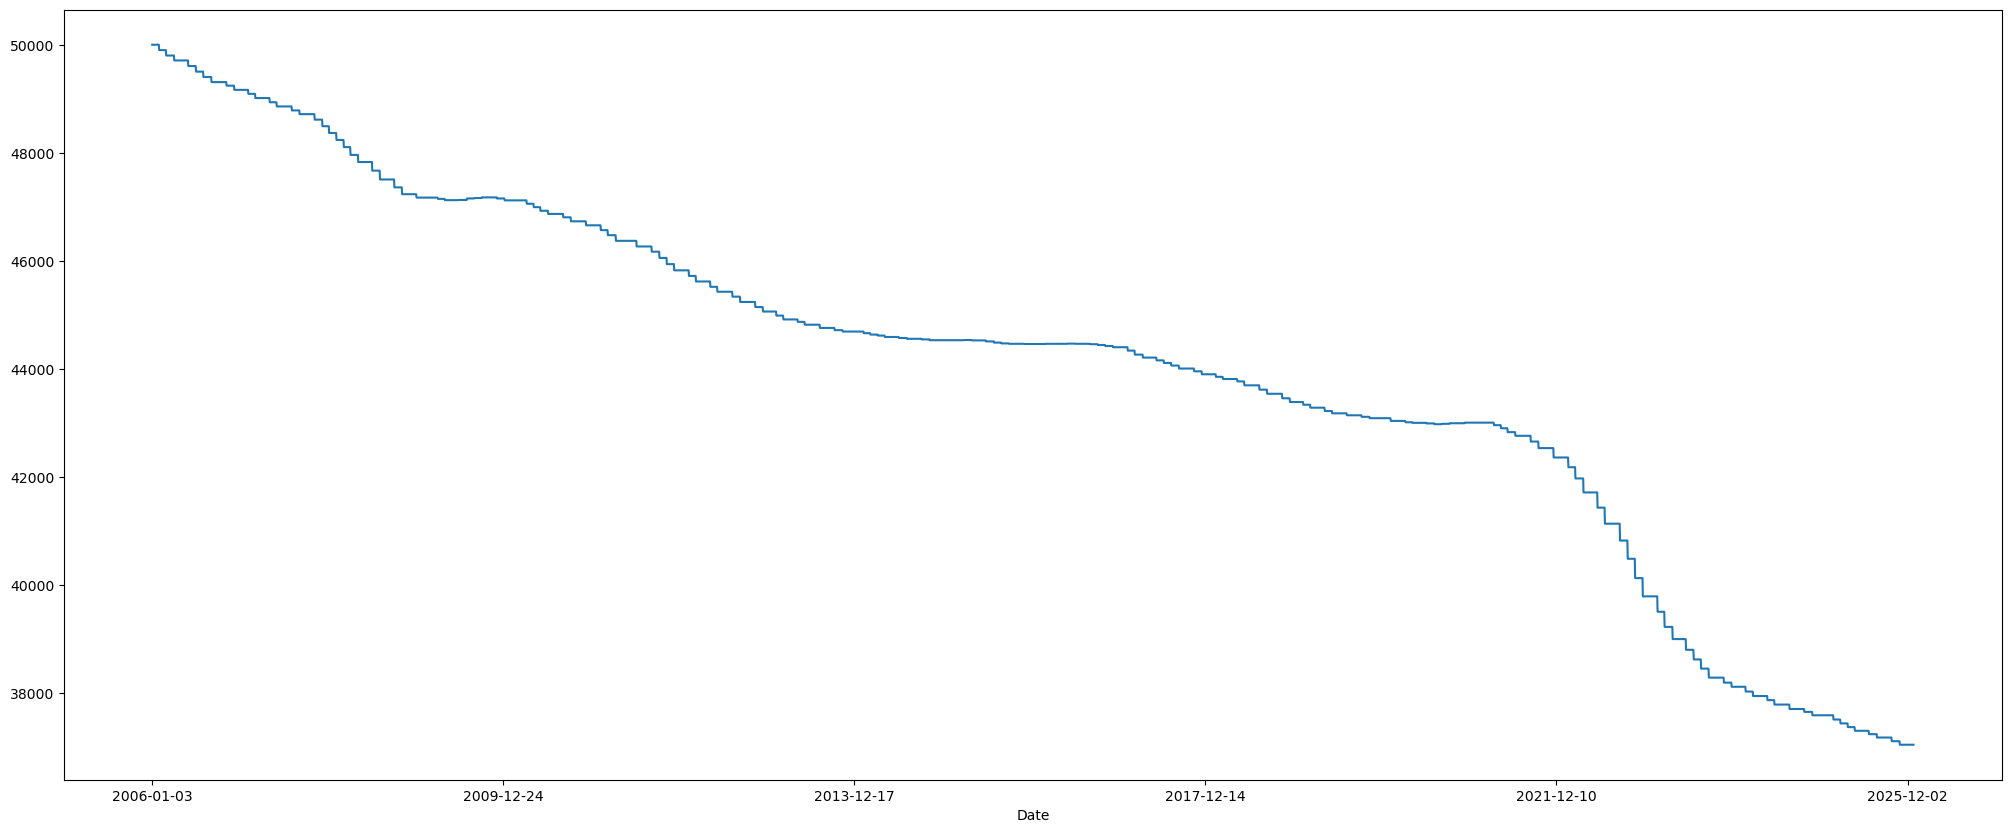

In [205]:
prices["Cash"].plot(figsize=(25,10))

In [216]:
# Stats for Cash
cagr_cash=CAGR(prices["Cash"])
print("CAGR of Cash --> ", cagr_cash*100,"%")
tot_return_cash=(prices["Cash"].iloc[-1] - prices["Cash"].iloc[0])/(prices["Cash"].iloc[0])
print("Total Return of Cash --> ", tot_return_cash*100,"%")
max_dd_cash=max_drawdown(prices["Cash"])
print("Max Drawdown of Cash is --> ", max_dd_cash*100,"%")
print("Minimum Daily Return -->", prices["Cash"].pct_change().min() * 100, "% on", prices["Cash"].pct_change().idxmin())
print("Maximum Daily Return -->", prices["Cash"].pct_change().max() * 100, "% on", prices["Cash"].pct_change().idxmax())
ann_vol_cash=ann_vol(prices["Cash"].pct_change())
print("The annualized volatility of Cash is --> ",ann_vol_cash*100,"%")

CAGR of Cash -->  -1.4942021606788924 %
Total Return of Cash -->  -25.90197139435375 %
Max Drawdown of Cash is -->  -25.90197139435375 %
Minimum Daily Return --> -0.8833333333333471 % on 2022-10-31
Maximum Daily Return --> 0.05833333333333801 % on 2009-07-31
The annualized volatility of Cash is -->  0.7231631229439797 %
